# Construcción de una capa de detección basada en PLN

In [17]:
#Montamos el notebook
from google.colab import drive
drive.mount('/content/drive')
DATASET_PATH = '/content/drive/MyDrive/TFG_Posdata/scripts/datasets/dataset_final.csv'
MODEL_PATH = '/content/drive/MyDrive/TFG_Posdata/models/distilbert_v1/'

#Imports
import torch
import transformers
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
import json
import onnxscript

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
#Obtenemos el dataframe desde el CSV que contiene el dataset
df = pd.read_csv(DATASET_PATH)

In [19]:
#Obtenemos las entradas (X) y salidas (y) del dataset que utilizar para el entrenamiento
X = df['text']
y = (df['label'] == 'spam').astype(int)

#Dividimos el dataset en un conjunto de entrenamiento (train) y prueba (test) y creamos un diccionario de datasets con
#el dataset de entrenamiento y pruebas generados

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({'train': train_dataset, 'test': test_dataset})

In [20]:
#Establecemos el modelo a utilizar
model_name = "distilbert-base-multilingual-cased"

#Tokenizamos el dataset al completo

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(input):
  return tokenizer(input['text'], padding='max_length', truncation=True, max_length=128)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(['text'])
tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset.set_format('torch')

#Cargamos el modelo preentrenado base
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


Map:   0%|          | 0/3452 [00:00<?, ? examples/s]

Map:   0%|          | 0/2302 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
#Definimos la configuración del modelo clasificador

def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    return {
        'f1': f1_score(labels, preds, average='weighted'),
        'accuracy': accuracy_score(labels, preds)
    }

training_args = TrainingArguments(
   output_dir=MODEL_PATH,
   per_device_train_batch_size=16,
   weight_decay=0.01,
   eval_strategy='epoch',
   save_strategy='epoch',
   load_best_model_at_end=True,
   metric_for_best_model='f1'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

#Entrenamos el modelo clasificador
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,No log,0.055603,0.984625,0.984796
2,No log,0.055793,0.984279,0.984361
3,0.068988,0.067729,0.982217,0.982189


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=648, training_loss=0.0561261984669132, metrics={'train_runtime': 214.0843, 'train_samples_per_second': 48.373, 'train_steps_per_second': 3.027, 'total_flos': 342958095120384.0, 'train_loss': 0.0561261984669132, 'epoch': 3.0})

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1915
           1       0.98      0.93      0.95       387

    accuracy                           0.98      2302
   macro avg       0.98      0.96      0.97      2302
weighted avg       0.98      0.98      0.98      2302



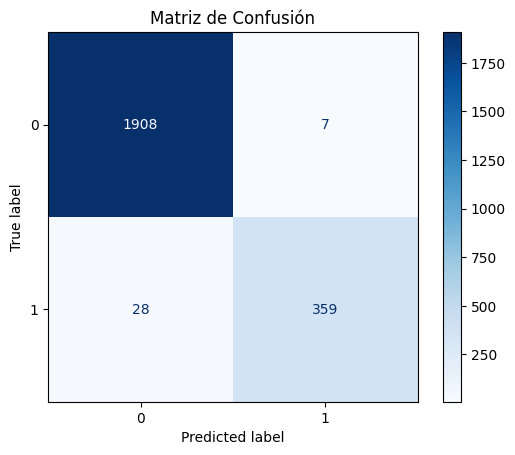

In [22]:
#Evaluamos la eficacia del modelo probándolo sobre el conjunto de prueba
predictions = trainer.predict(tokenized_dataset['test'])

y_pred = np.argmax(predictions.predictions, axis=1)
y_test = predictions.label_ids

#Imprimimos sus principales métricas
print(classification_report(y_test, y_pred))

#Imprimimos su matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

In [23]:
#Guardamos el modelo y la configuración usada para entrenarlo

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)
print("Modelo y tokenizer guardados con éxito")

nombre_config = 'own_config.json'
config = {
    "threshold": 0.5,
    "base_model": "distilbert-base-multilingual-cased",
    "model_version": "distilbert_v1"
}
with open(MODEL_PATH + nombre_config, 'w') as f:
    json.dump(config, f)
print("Configuración guardada con éxito")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo y tokenizer guardados con éxito
Configuración guardada con éxito


In [24]:
#Exportamos el modelo a ONNX

model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model.eval()

dummy_input = tokenizer("dummy text", return_tensors="pt",
                         padding='max_length', truncation=True, max_length=128)

torch.onnx.export(
    model,
    (dummy_input['input_ids'], dummy_input['attention_mask']),
    MODEL_PATH
     + 'model.onnx',
    input_names=['input_ids', 'attention_mask'],
    output_names=['logits'],
    dynamic_axes={
        'input_ids': {0: 'batch_size'},
        'attention_mask': {0: 'batch_size'}
    },
    opset_version=14
)
print("Exportado correctamente")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipykernel_5592/1181604603.py:10: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0329 18:10:18.866000 5592 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0329 18:10:19.450000 5592 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `DistilBertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DistilBertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/no_previous_version.h:24: adapt: Assertion `

[torch.onnx] Translate the graph into ONNX... ✅
Applied 29 of general pattern rewrite rules.
Exportado correctamente
